In [19]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My\ Drive/Colab\ Notebooks/WignerCamp2026
    !pip install optuna --quiet
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running on Local computer


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

from artificial_dataset import ClassifierMetrics, make_anomaly_dataset

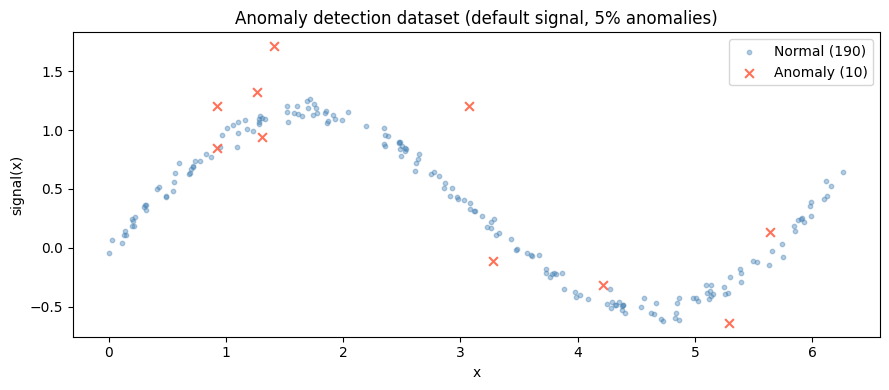

In [21]:
x, Y, labels = make_anomaly_dataset(
    n_samples=200, anomaly_fraction=0.05, random_state=0
)

normal = labels == 0
anomaly = labels == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x[normal],
    Y[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x[anomaly],
    Y[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
print(f"x:")
print(x.shape)
print(x[:5])
print(f"Y:")
print(Y.shape)
print(Y[:5])
print(f"class:")
print(labels.shape)
print(labels[:5])

x:
torch.Size([200])
tensor([0.0078, 0.0322, 0.1117, 0.1280, 0.1403])
Y:
torch.Size([200, 1])
tensor([[-0.0435],
        [ 0.0646],
        [ 0.0390],
        [ 0.1101],
        [ 0.1407]])
class:
torch.Size([200])
tensor([0, 0, 0, 0, 0])


In [26]:
peaks, properties = find_peaks(Y[:, 0], prominence=0.1)
print(peaks, properties)

[ 33  37  44  52  62  93 104 114 136 138 150 158 164 168 176 182 193 196] {'prominences': array([0.35053462, 0.18242562, 0.37958181, 1.75708272, 0.20153177,
       0.14345837, 0.79726055, 0.35336608, 0.11531046, 0.13051304,
       0.13297179, 0.14703962, 0.11729321, 0.30486196, 0.11318119,
       0.21519344, 0.11910412, 0.12902018]), 'left_bases': array([  0,  34,   0,   0,  55,  90, 103, 113, 135, 137, 148, 155, 155,
       155, 174, 174, 174, 174]), 'right_bases': array([ 34,  38,  50, 174, 174, 103, 174, 174, 155, 155, 155, 159, 166,
       174, 178, 185, 194, 197])}


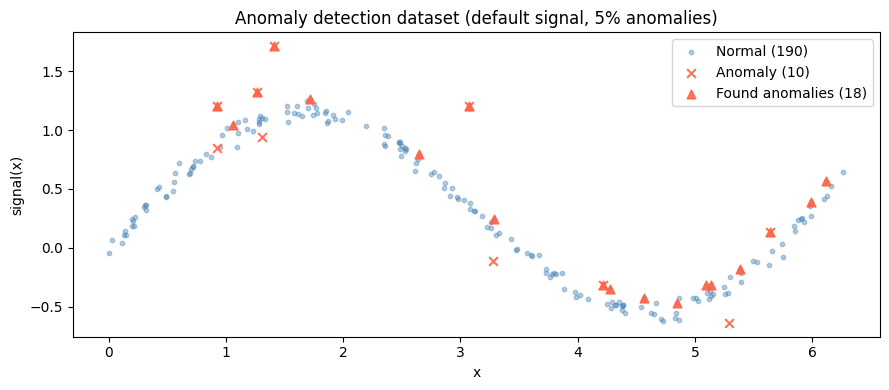

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x[normal],
    Y[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x[anomaly],
    Y[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.scatter(
    x[peaks],
    Y[peaks, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="^",
    label=f"Found anomalies ({peaks.shape[0]})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
y_pred = torch.zeros(Y.shape[0])
y_pred[peaks] = 1

m = ClassifierMetrics(y_true=labels, y_pred=y_pred)

print(f"Accuracy  : {m.accuracy:.3f}")
print(f"Precision : {m.precision:.3f}")
print(f"Recall    : {m.recall:.3f}")
print(f"F1 score  : {m.f1_score:.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(m.confusion_matrix)


Accuracy  : 0.920
Precision : 0.656
Recall    : 0.768
F1 score  : 0.693

Confusion matrix (rows = true, cols = predicted):
tensor([[178,  12],
        [  4,   6]])
